In [3]:
import pandas as pd

In [4]:
df_single_h = pd.read_csv('1인가구_성별_연령.csv', encoding='UTF-8')
df_all_h = pd.read_csv('상주인구_자치구.csv', encoding='UTF-8')
df_store = pd.read_csv('점포_자치구.csv', encoding='UTF-8')

1인가구 비율 계산 = (5년 평균 1인가구 수 / 5년 평균 전체가구 수)

In [5]:
# 1인가구 수 계산
# print(df_single_h.head())
df_single_h = df_single_h.groupby(['자치구명', '기준연도'], as_index=False).sum(numeric_only=True)
df_single_h['sum_all_ages'] = df_single_h.iloc[:, 2:].sum(axis=1)
# print(df_single_h.head(20))

In [6]:
# 전체가구 수 계산
# print(df_all_h.info())
# 필요한 컬럼만 선택
df = df_all_h[
    ['기준_년분기_코드', '자치구_코드_명', '총_가구_수']].copy()
# 연도 컬럼 생성
df['기준연도'] = (df['기준_년분기_코드'].astype(str).str[:4].astype(int))
# 2019 ~ 2023만 필터링
df = df[(df['기준연도'] >= 2019) &(df['기준연도'] <= 2023)]
# 자치구 + 연도 기준으로 분기 합산
df = (df.groupby(['자치구_코드_명', '기준연도'], as_index=False)['총_가구_수'].sum())
# print(df.head(20))

페업 비율 계산 = (5년 평균 폐업점포 수 / 5년 평균 전체점포 수)
print(df_store.info())
print(df_store['서비스_업종_코드_명'].unique())

In [7]:
target_stores = ['청과상','수산물판매','육류판매','미곡판매','주류도매','편의점','슈퍼마켓','커피-음료','호프-간이주점',
    '분식전문점','치킨전문점','패스트푸드점','제과점','양식음식점','일식음식점','중식음식점','한식음식점']
# 필요한 업종 + 컬럼만 선택
df_food = df_store[df_store['서비스_업종_코드_명'].isin(target_stores)][
    ['기준_년분기_코드','자치구_코드_명','점포_수','폐업_점포_수']].copy()
# 연도 추출
df_food['기준연도'] = (df_food['기준_년분기_코드'].astype(str).str[:4].astype(int))
# 2019~2023 필터링
df_food = df_food[(df_food['기준연도'] >= 2019) &(df_food['기준연도'] <= 2023)]
# 연 단위 집계
df_food = (df_food.groupby(['자치구_코드_명', '기준연도'], as_index=False)
    .agg({
        '점포_수': 'mean',
        '폐업_점포_수': 'sum'
    }))

데이터 병합

In [8]:
# 1인 가구 수만 추출 + 컬럼명 변경
df_single_merge = df_single_h[['자치구명', '기준연도', 'sum_all_ages']].rename(columns={'sum_all_ages': '1인_가구_수'})
# df_food 필요한 컬럼만
df_food_merge = df_food[['자치구_코드_명', '기준연도', '점포_수', '폐업_점포_수']]
# df 컬럼명 통일
df = df.rename(columns={'자치구_코드_명': '자치구명'})
# 1인 가구 merge
df = df.merge(df_single_merge,on=['자치구명', '기준연도'],how='left')
# 음식업 데이터 merge
df = df.merge(df_food_merge.rename(columns={'자치구_코드_명': '자치구명'}),on=['자치구명', '기준연도'],how='left')

In [9]:
# 1인가구 대비 폐업률 계산
df_mean = (df.drop(columns='기준연도').groupby('자치구명', as_index=False).mean())
print(df_mean.head(30))

    자치구명     총_가구_수   1인_가구_수        점포_수  폐업_점포_수
0    강남구   932262.0   71489.2  753.926471   2543.8
1    강동구   758297.6   55020.8  345.782353   1187.0
2    강북구   579846.2   48139.4  253.788235    866.0
3    강서구  1058087.8   93036.6  442.208824   1619.4
4    관악구  1086141.6  136305.8  356.102941   1303.8
5    광진구   663134.2   65701.0  315.585294   1078.0
6    구로구   709767.8   54797.2  320.611765   1046.4
7    금천구   450636.8   45900.0  246.117647    766.0
8    노원구   870469.0   59749.4  275.000000    941.0
9    도봉구   553042.4   37331.8  201.114706    630.6
10  동대문구   661008.8   64699.0  383.400000   1060.6
11   동작구   728915.6   67729.0  314.064706    902.2
12   마포구   681072.8   66344.8  563.435294   1898.8
13  서대문구   569925.4   51912.4  271.658824    864.8
14   서초구   689052.4   45608.6  466.011765   1336.6
15   성동구   542438.8   44735.6  369.641176    921.8
16   성북구   764539.0   64139.4  287.332353    917.4
17   송파구  1116286.6   78286.0  723.200000   1916.0
18   양천구   715509.0   42272.4  

In [10]:
df_mean['sh_closure_ratio'] = (
    (df_mean['폐업_점포_수'] / df_mean['점포_수']) /
    (df_mean['1인_가구_수'] / df_mean['총_가구_수']))

In [11]:
print("======1인가구 대비 폐업률 보기=======")
print(df_mean[['자치구명', 'sh_closure_ratio']].sort_values(by='sh_closure_ratio',ascending=False))

======1인가구 대비 폐업률 보기=======
    자치구명  sh_closure_ratio
18   양천구         60.373158
8    노원구         49.851323
21   은평구         48.323745
1    강동구         47.310842
9    도봉구         46.450419
0    강남구         43.999882
14   서초구         43.332135
6    구로구         42.274278
3    강서구         41.648044
2    강북구         41.101583
24   중랑구         40.252611
16   성북구         38.058263
17   송파구         37.777107
13  서대문구         34.949323
12   마포구         34.595676
5    광진구         34.477157
19  영등포구         32.147987
20   용산구         30.962203
11   동작구         30.916212
7    금천구         30.556245
15   성동구         30.238054
4    관악구         29.174776
22   종로구         28.966490
10  동대문구         28.262410
23    중구         25.344440


1인 가구 증가에 따른 폐업률 보기

In [12]:
df_growth = df.copy()

In [13]:
# 정렬
df_growth = df_growth.sort_values(['자치구명', '기준연도'])

In [14]:
# 1인가구 비중
df_growth['1인가구_비중'] = (df_growth['1인_가구_수'] /df_growth['총_가구_수'])

In [15]:
# 1인가구 비중 증가율
df_growth['1인가구비중_증가율'] = (df_growth.groupby('자치구명')['1인가구_비중'].pct_change())

In [16]:
# 폐업 증가율
df_growth['폐업_증가율'] = (df_growth.groupby('자치구명')['폐업_점포_수'].pct_change())

In [17]:
# 증가율 대비 지표
df_growth['sh_closure_growth_ratio'] = (
    df_growth['폐업_증가율'] /
    df_growth['1인가구비중_증가율']
)
df_growth = df_growth[df_growth['기준연도'] != 2019]
df_growth = (df_growth.drop(columns='기준연도').groupby('자치구명', as_index=False).mean())

In [18]:
print("======1인 가구 증가에 따른 폐업률 보기=======")
print(df_growth[['자치구명', 'sh_closure_growth_ratio']].sort_values( by='sh_closure_growth_ratio',ascending=False))

======1인 가구 증가에 따른 폐업률 보기=======
    자치구명  sh_closure_growth_ratio
7    금천구                 3.454858
12   마포구                 2.347896
3    강서구                 1.726035
18   양천구                 1.152194
21   은평구                 1.042604
11   동작구                 0.985065
17   송파구                 0.977245
9    도봉구                 0.902840
24   중랑구                 0.892308
5    광진구                 0.776550
4    관악구                 0.589690
13  서대문구                 0.526524
8    노원구                 0.509474
1    강동구                 0.377572
6    구로구                 0.369265
2    강북구                 0.311143
19  영등포구                 0.201541
20   용산구                 0.011446
0    강남구                -0.004461
15   성동구                -0.070657
10  동대문구                -0.131104
22   종로구                -0.799831
14   서초구                -0.991066
16   성북구                -1.738572
23    중구                -3.141406


## EDA

In [29]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', None)

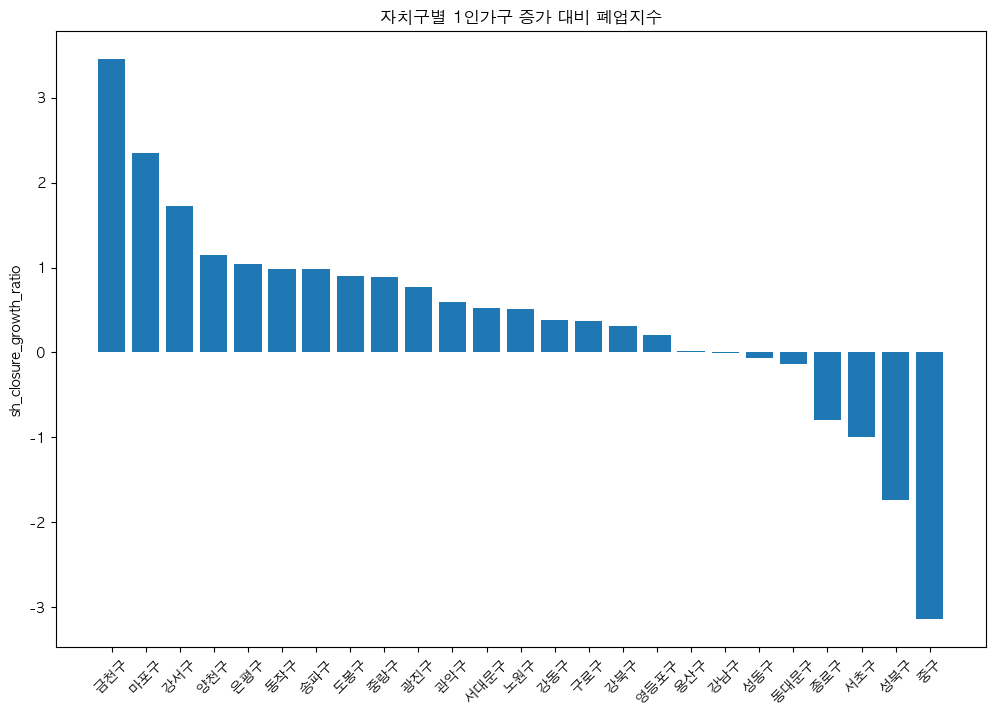

In [22]:
plt.figure(figsize=(12, 8))

plot_df = df_growth.sort_values(
    by='sh_closure_growth_ratio',
    ascending=False
)

plt.bar(
    plot_df['자치구명'],
    plot_df['sh_closure_growth_ratio']
)

plt.xticks(rotation=45)
plt.ylabel('sh_closure_growth_ratio')
plt.title('자치구별 1인가구 증가 대비 폐업지수')

plt.show()

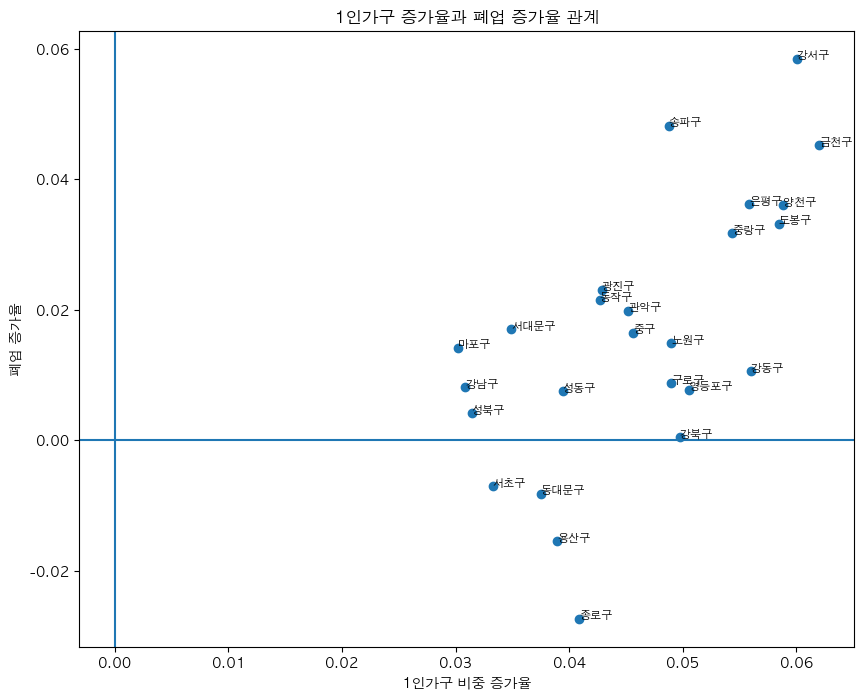

In [23]:
plt.figure(figsize=(10, 8))

plt.scatter(
    df_growth['1인가구비중_증가율'],
    df_growth['폐업_증가율']
)

for i in range(len(df_growth)):
    plt.text(
        df_growth['1인가구비중_증가율'].iloc[i],
        df_growth['폐업_증가율'].iloc[i],
        df_growth['자치구명'].iloc[i],
        fontsize=8
    )

plt.axhline(0)
plt.axvline(0)

plt.xlabel('1인가구 비중 증가율')
plt.ylabel('폐업 증가율')

plt.title('1인가구 증가율과 폐업 증가율 관계')

plt.show()

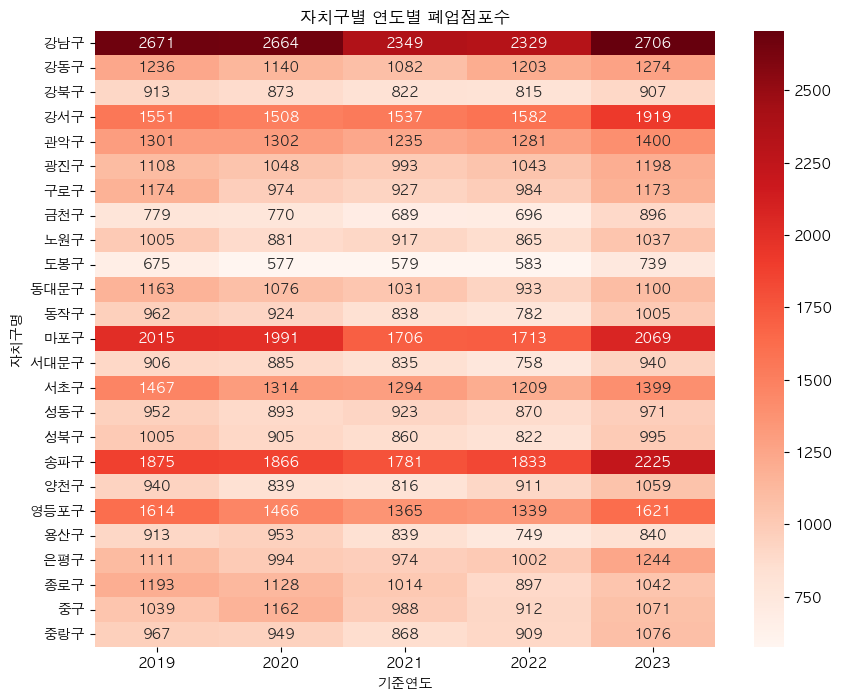

In [31]:
pivot_df = df.pivot(
    index='자치구명',
    columns='기준연도',
    values='폐업_점포_수'
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    pivot_df,
    annot=True,
    fmt='.0f',
    cmap='Reds'
)

plt.title('자치구별 연도별 폐업점포수')

plt.show()